In [11]:
import pandas as pd


In [12]:
df3 = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union/Nick/churn_full_cleaned_numbers.csv")
df3.info()

from sklearn.model_selection import train_test_split

X = df3.drop(['Churned'], axis=1)
y = df3['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GuestID                6954 non-null   int64  
 1   AllInclusive           6786 non-null   float64
 2   Age                    6809 non-null   float64
 3   VIP                    6796 non-null   float64
 4   RoomService            6490 non-null   float64
 5   Dining                 6466 non-null   float64
 6   Retail                 6790 non-null   float64
 7   Spa                    6806 non-null   float64
 8   Entertainment          6815 non-null   float64
 9   LoyaltyPoints          6954 non-null   int64  
 10  SurveyScore            6954 non-null   int64  
 11  DaysSinceEmail         6954 non-null   int64  
 12  Churned                6954 non-null   int64  
 13  SharedRoom             6954 non-null   int64  
 14  PromoCodeUsed          6954 non-null   int64  
 15  Days

# 1. XGBoost

Test ROC-AUC:        0.855
Best iteration:      129


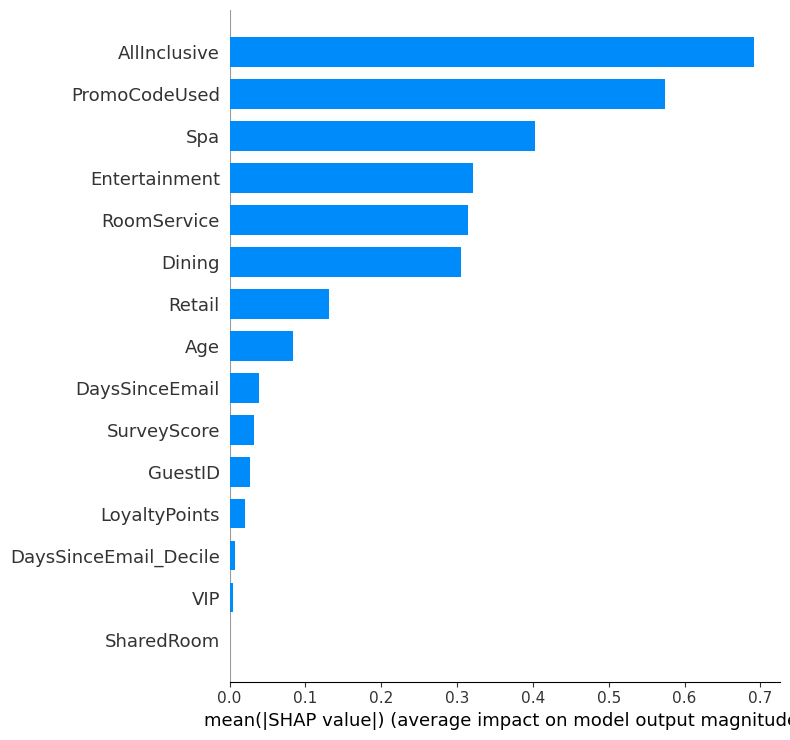

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import shap

# Class imbalance: scale_pos_weight ≈ neg / pos in your training data
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=neg / pos,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

probs = xgb.predict_proba(X_test)[:, 1]
print(f"Test ROC-AUC:        {roc_auc_score(y_test, probs):.3f}")
print(f"Best iteration:      {xgb.best_iteration}")

# Explain individual predictions with SHAP — critical for stakeholder trust
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
test = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union/datasets/resort_test.csv")
test.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GuestID         1739 non-null   int64  
 1   BookingDate     1739 non-null   object 
 2   PromoCode       951 non-null    object 
 3   Region          1707 non-null   object 
 4   AllInclusive    1690 non-null   float64
 5   Room            1651 non-null   object 
 6   PackageType     1710 non-null   object 
 7   Age             1612 non-null   float64
 8   VIP             1694 non-null   float64
 9   RoomService     1627 non-null   float64
 10  Dining          1614 non-null   float64
 11  Retail          1700 non-null   float64
 12  Spa             1707 non-null   float64
 13  Entertainment   1695 non-null   float64
 14  LoyaltyPoints   1739 non-null   int64  
 15  SurveyScore     1739 non-null   int64  
 16  DaysSinceEmail  1739 non-null   int64  
 17  BookingChannel  1739 non-null   o

In [16]:
#Drop the BookingDate, PromoCode, Region, Room, PackageType, BookingChannel, AgeGroup, and ReferralSource columns from the test set
test = test.drop(["BookingDate", "PromoCode", "Region", "Room", "PackageType", "BookingChannel", "AgeGroup", "ReferralSource"], axis=1)
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1739 entries, 0 to 1738
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   GuestID         1739 non-null   int64  
 1   AllInclusive    1690 non-null   float64
 2   Age             1612 non-null   float64
 3   VIP             1694 non-null   float64
 4   RoomService     1627 non-null   float64
 5   Dining          1614 non-null   float64
 6   Retail          1700 non-null   float64
 7   Spa             1707 non-null   float64
 8   Entertainment   1695 non-null   float64
 9   LoyaltyPoints   1739 non-null   int64  
 10  SurveyScore     1739 non-null   int64  
 11  DaysSinceEmail  1739 non-null   int64  
dtypes: float64(8), int64(4)
memory usage: 163.2 KB


In [15]:
probs = xgb.predict(test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:BookingDate: object, PromoCode: object, Region: object, Room: object, PackageType: object, BookingChannel: object, AgeGroup: object, ReferralSource: object